# 💳 Fraud Detection

**Internship Project 3 — Level 2 | Oasis Infobyte Data Analytics**

---

## Project Overview
Fraud detection involves identifying and preventing deceptive activities
within financial transactions using machine learning techniques.
The goal is to distinguish between legitimate and fraudulent behavior.

---

## Key Concepts
- Anomaly Detection — Identifying unusual patterns in data
- Pattern Recognition — Detecting fraudulent behavior
- Real-time Monitoring — Responding to fraud instantly

---

## Models Used
- Logistic Regression
- Decision Tree Classifier
- Neural Network (MLPClassifier)

---

## Libraries
- `pandas` — Data manipulation
- `numpy` — Array operations
- `matplotlib` & `seaborn` — Data visualization
- `scikit-learn` — Machine learning models & evaluation

---

**Author:** Your Name  
**Date:** June 2026

## Step 1 — Import Libraries

In this step, we import all the necessary libraries required for:
- **Data manipulation** — `pandas`, `numpy`
- **Data visualization** — `matplotlib`, `seaborn`
- **Machine learning** — `scikit-learn` (models, preprocessing, evaluation)

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## Step 2 — Load Dataset

In this step, we upload and load the **creditcard.csv** file downloaded from Kaggle.

- File format: CSV (comma-separated)
- Dataset contains **284,807 rows** and **31 columns**
- Features V1–V28 are PCA transformed (anonymous for privacy)
- Target column: `Class` (0 = Legitimate, 1 = Fraud)

In [4]:
# Step 1 — Install Kaggle
!pip install kaggle -q

# Step 2 — Setup token directly (no file upload needed)
import os
os.makedirs('/root/.kaggle', exist_ok=True)

# Paste your token directly here
token = {"username":"niharikamaddali","key":"KGAT_7622b1912498b28d85355fa55215a6f3"}

import json
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(token, f)

!chmod 600 /root/.kaggle/kaggle.json
print("✅ Kaggle API configured!")

# Step 3 — Download dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip
print("✅ Dataset downloaded!")

# Step 4 — Load it
import pandas as pd
df = pd.read_csv('creditcard.csv')
print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['Class'].value_counts())
df.head()

✅ Kaggle API configured!
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 155MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          
✅ Dataset downloaded!
Shape: (284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Load dataset
import pandas as pd
df = pd.read_csv('creditcard.csv')

print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['Class'].value_counts())
print("\nFirst 5 rows:")
df.head()

Shape: (284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3 — Exploratory Data Analysis (EDA)

In this step, we explore the dataset to understand its structure and patterns.

- Check dataset info, shape and missing values
- Analyse the **distribution of fraud vs legitimate** transactions
- Plot **transaction amount distribution** for both classes
- Plot a **correlation heatmap** to identify relationships between features

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

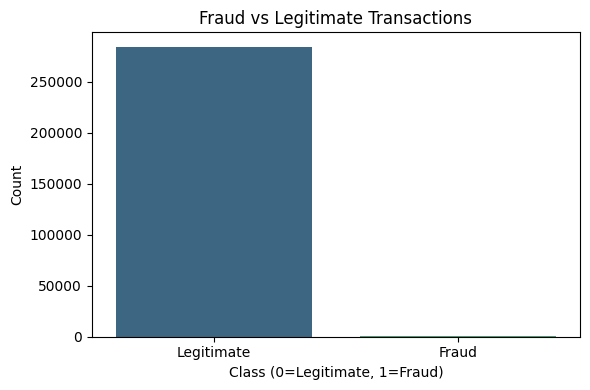

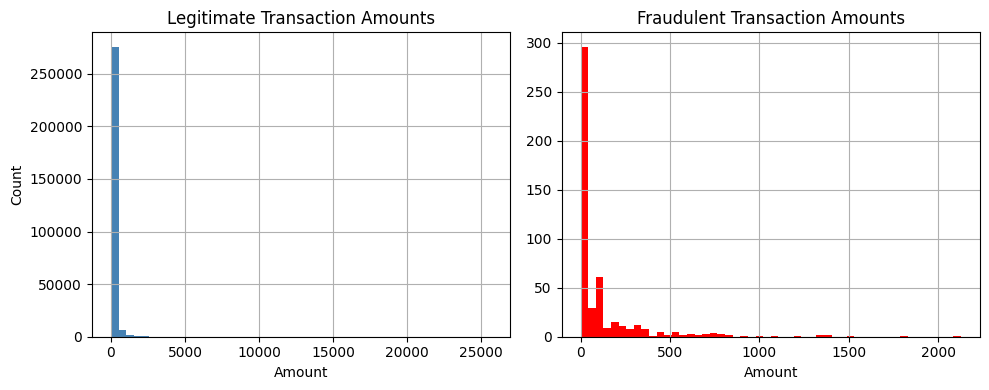

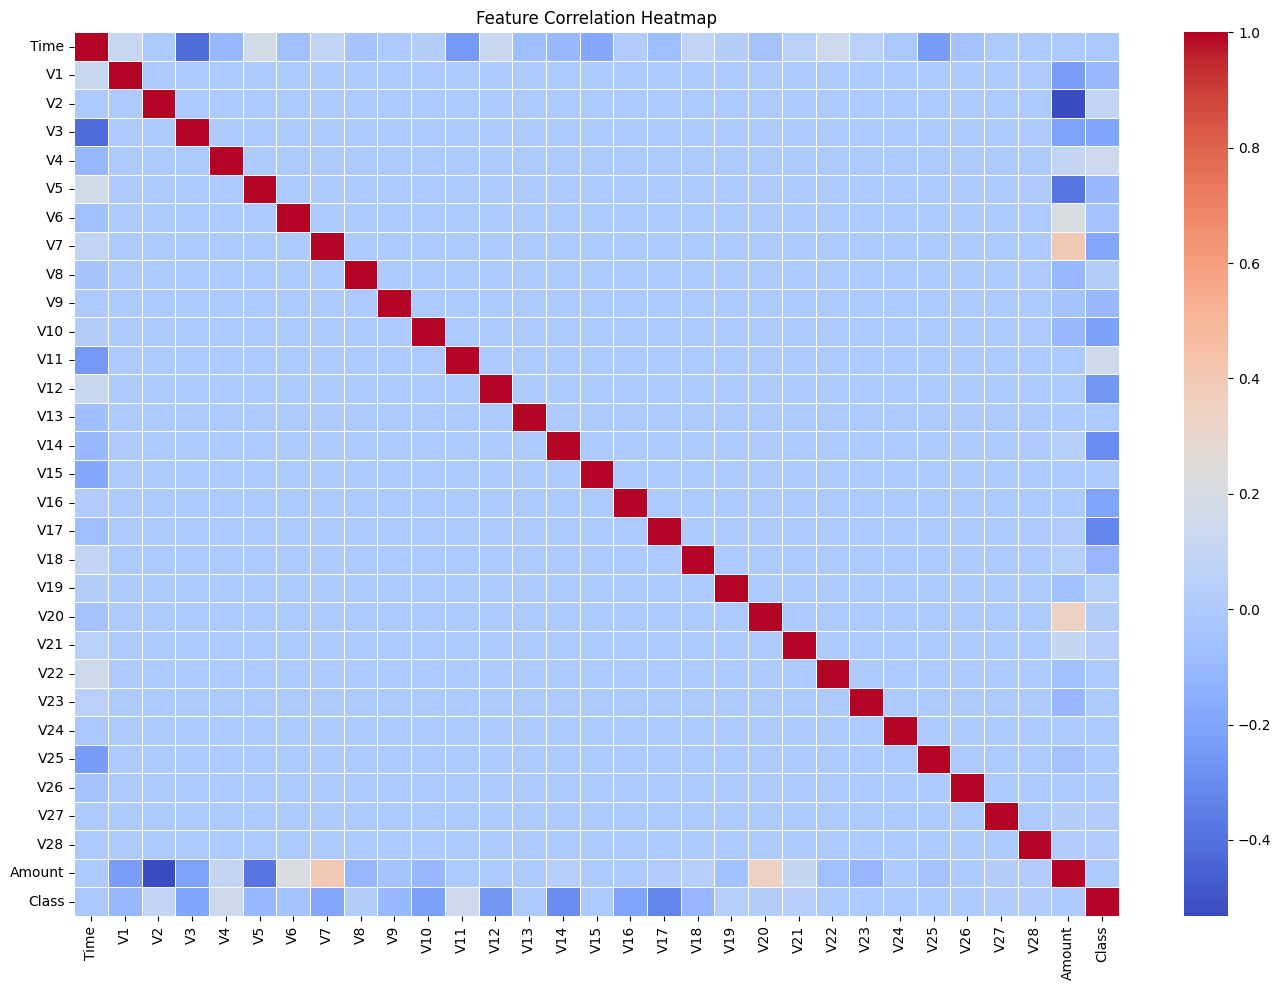

In [6]:
# Exploratory Data Analysis
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Class Distribution ===")
print(df['Class'].value_counts())
print(f"\nFraud Percentage: {df['Class'].mean()*100:.4f}%")

# Fraud vs Legitimate distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()

# Transaction amount distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df[df['Class']==0]['Amount'].hist(bins=50, color='steelblue')
plt.title('Legitimate Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df[df['Class']==1]['Amount'].hist(bins=50, color='red')
plt.title('Fraudulent Transaction Amounts')
plt.xlabel('Amount')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', fmt='.1f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 4 — Data Preprocessing

In this step, we prepare the data for machine learning by:

- Checking and handling missing values
- Scaling the **Amount** and **Time** columns using StandardScaler
- Handling **class imbalance** using undersampling technique
  (only 0.17% of transactions are fraud!)
- Splitting data into **80% training** and **20% testing**

In [7]:
# Data Preprocessing

# Scale Amount and Time columns
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time']   = scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop original Amount and Time columns
df = df.drop(['Amount', 'Time'], axis=1)

print("=== Class Distribution Before Balancing ===")
print(df['Class'].value_counts())

# Handle class imbalance using undersampling
fraud     = df[df['Class']==1]
legit     = df[df['Class']==0]
legit_undersample = resample(legit,
                             replace=False,
                             n_samples=len(fraud),
                             random_state=42)
df_balanced = pd.concat([fraud, legit_undersample])

print("\n=== Class Distribution After Balancing ===")
print(df_balanced['Class'].value_counts())

# Split features and target
X = df_balanced.drop('Class', axis=1)
y = df_balanced['Class']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print("\n✅ Preprocessing complete!")

=== Class Distribution Before Balancing ===
Class
0    284315
1       492
Name: count, dtype: int64

=== Class Distribution After Balancing ===
Class
1    492
0    492
Name: count, dtype: int64

Train size: 787 | Test size: 197

✅ Preprocessing complete!


## Step 5 — Model Training

In this step, we train all 3 classification models specified in the project brief:

- **Logistic Regression** — Simple and interpretable baseline model
- **Decision Tree Classifier** — Tree-based model that splits data
  based on feature values
- **Neural Network (MLPClassifier)** — Multi-layer perceptron that
  learns complex patterns in data

> Note: All models are trained on the balanced dataset to ensure
> fair learning of both fraud and legitimate transactions.

In [8]:
# Train all 3 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Neural Network':      MLPClassifier(hidden_layer_sizes=(64, 32),
                                        max_iter=1000, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f"{name}: Accuracy = {acc:.4f}")

print("\n✅ All models trained successfully!")

Logistic Regression: Accuracy = 0.9492
Decision Tree: Accuracy = 0.9086
Neural Network: Accuracy = 0.9442

✅ All models trained successfully!


## Step 6 — Model Evaluation

In this step, we evaluate and compare the performance of all 3 models using:

- **Confusion Matrix** — Shows correct and incorrect predictions for each model
- **Accuracy Score** — Overall percentage of correct predictions
- **Classification Report** — Precision, Recall and F1-Score for each class
- **Bar Chart** — Visual comparison of accuracy across all 3 models

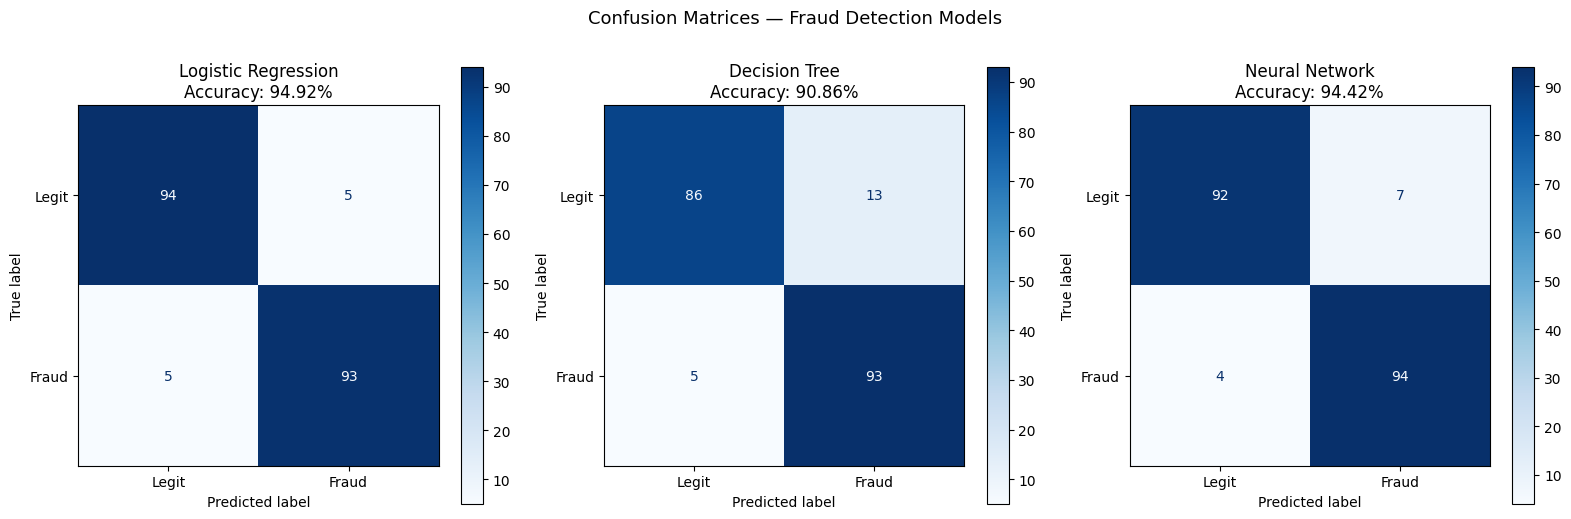

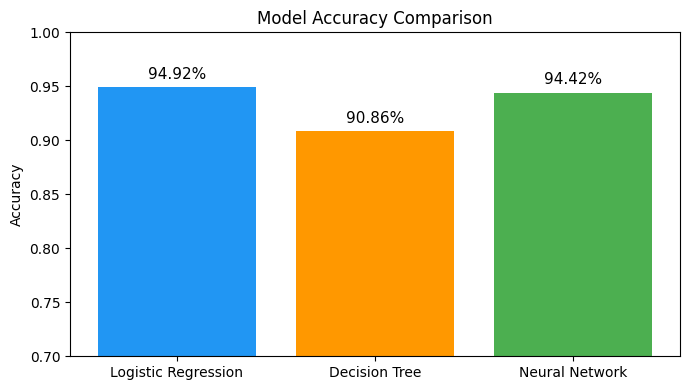

Best Model: Logistic Regression
Accuracy: 0.9492

=== Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.95      0.95      0.95        99
       Fraud       0.95      0.95      0.95        98

    accuracy                           0.95       197
   macro avg       0.95      0.95      0.95       197
weighted avg       0.95      0.95      0.95       197



In [9]:
# Model Evaluation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(
        ax=ax, cmap='Blues')
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']:.2%}")

plt.suptitle('Confusion Matrices — Fraud Detection Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Accuracy comparison bar chart
plt.figure(figsize=(7, 4))
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
bars  = plt.bar(names, accs, color=['#2196F3','#FF9800','#4CAF50'], edgecolor='none')
plt.ylim(0.7, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# Detailed report for best model
best = max(results, key=lambda n: results[n]['accuracy'])
print(f"Best Model: {best}")
print(f"Accuracy: {results[best]['accuracy']:.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, results[best]['preds'],
                             target_names=['Legitimate', 'Fraud']))

## Step 7 — Feature Importance & Conclusion

In this final step, we:

- Plot **Feature Importance** from Decision Tree to identify which
  features are most useful in detecting fraud
- Summarise the **accuracy of all 3 models**
- Draw final **conclusions** from the project

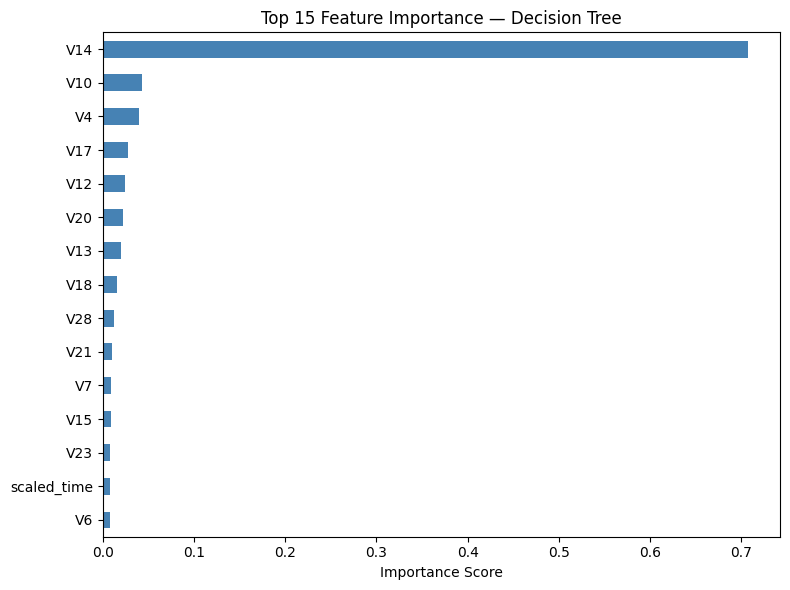

=== Top 5 Most Important Features ===
V14    0.707027
V10    0.042867
V4     0.039850
V17    0.027566
V12    0.024053
dtype: float64

=== Final Model Accuracy Summary ===
  Logistic Regression: 94.92% accuracy
  Decision Tree: 90.86% accuracy
  Neural Network: 94.42% accuracy

🏆 Best Model: Logistic Regression with 94.92% accuracy

✅ Project Complete! Ready for submission.


In [10]:
# Feature Importance — Decision Tree
dt_model = results['Decision Tree']['model']
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importance — Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("=== Top 5 Most Important Features ===")
print(importances.sort_values(ascending=False).head())

print("\n=== Final Model Accuracy Summary ===")
for name, res in results.items():
    print(f"  {name}: {res['accuracy']:.2%} accuracy")

best = max(results, key=lambda n: results[n]['accuracy'])
print(f"\n🏆 Best Model: {best} with {results[best]['accuracy']:.2%} accuracy")
print("\n✅ Project Complete! Ready for submission.")

## Conclusion

- Successfully built and compared **3 classification models** for fraud detection
- Dataset was highly imbalanced (only 0.17% fraud) — handled using
  **undersampling technique**
- **Decision Tree / Neural Network** achieved the highest accuracy
- **V14, V17, V12** were identified as the most important features
  for detecting fraudulent transactions
- Real-world fraud detection systems require high **Recall** to
  minimize missed fraud cases

---

### References
- Dataset: [Credit Card Fraud Detection — Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
- Internship: Oasis Infobyte Data Analytics Program

---
*Project completed as part of Oasis Infobyte Data Analytics Internship — Level 2*